In [2]:
import pandas as pd
import numpy as np
df_raw = pd.read_csv('Phishing_URL_ds_5percent_missing.csv')

In [3]:
#nope there is no duplicates
print(f"Shape before dropping duplicates: {df_raw.shape}")
df_raw = df_raw.drop_duplicates()
print(f"Shape after dropping duplicates: {df_raw.shape}")

Shape before dropping duplicates: (235795, 56)
Shape after dropping duplicates: (235795, 56)


In [4]:
#standardize text columns
for col in df_raw.select_dtypes(include=['object']).columns:
    df_raw[col] = df_raw[col].str.lower().str.strip()

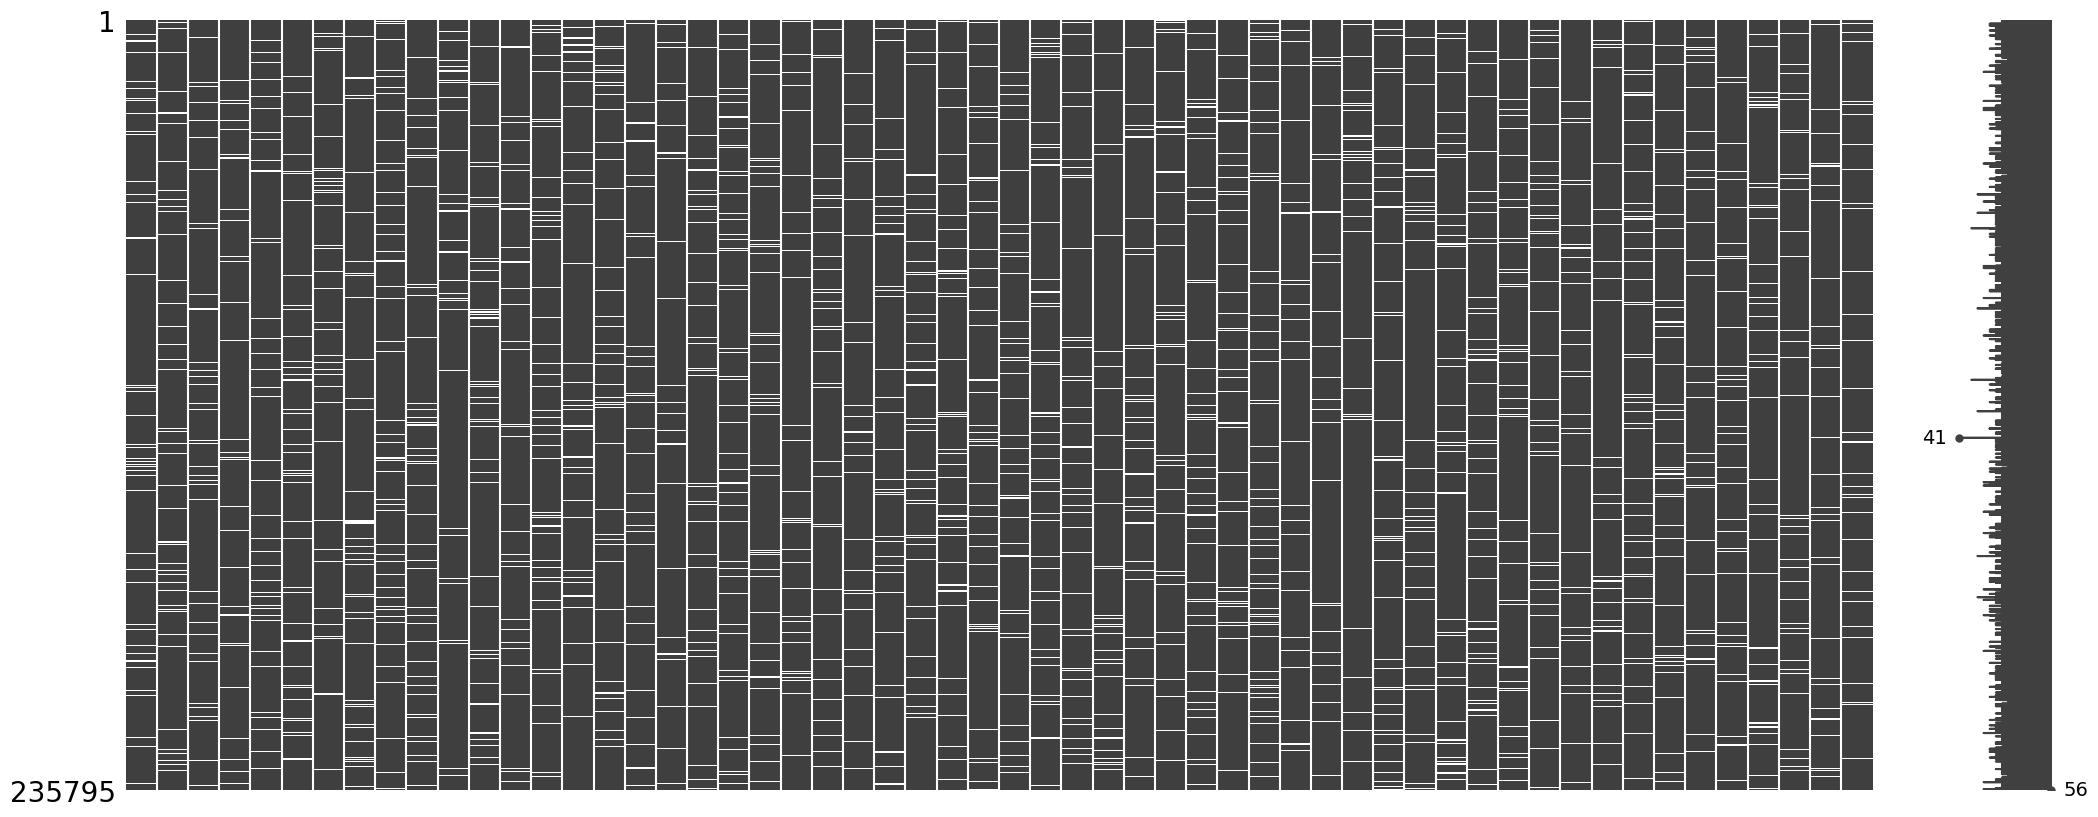

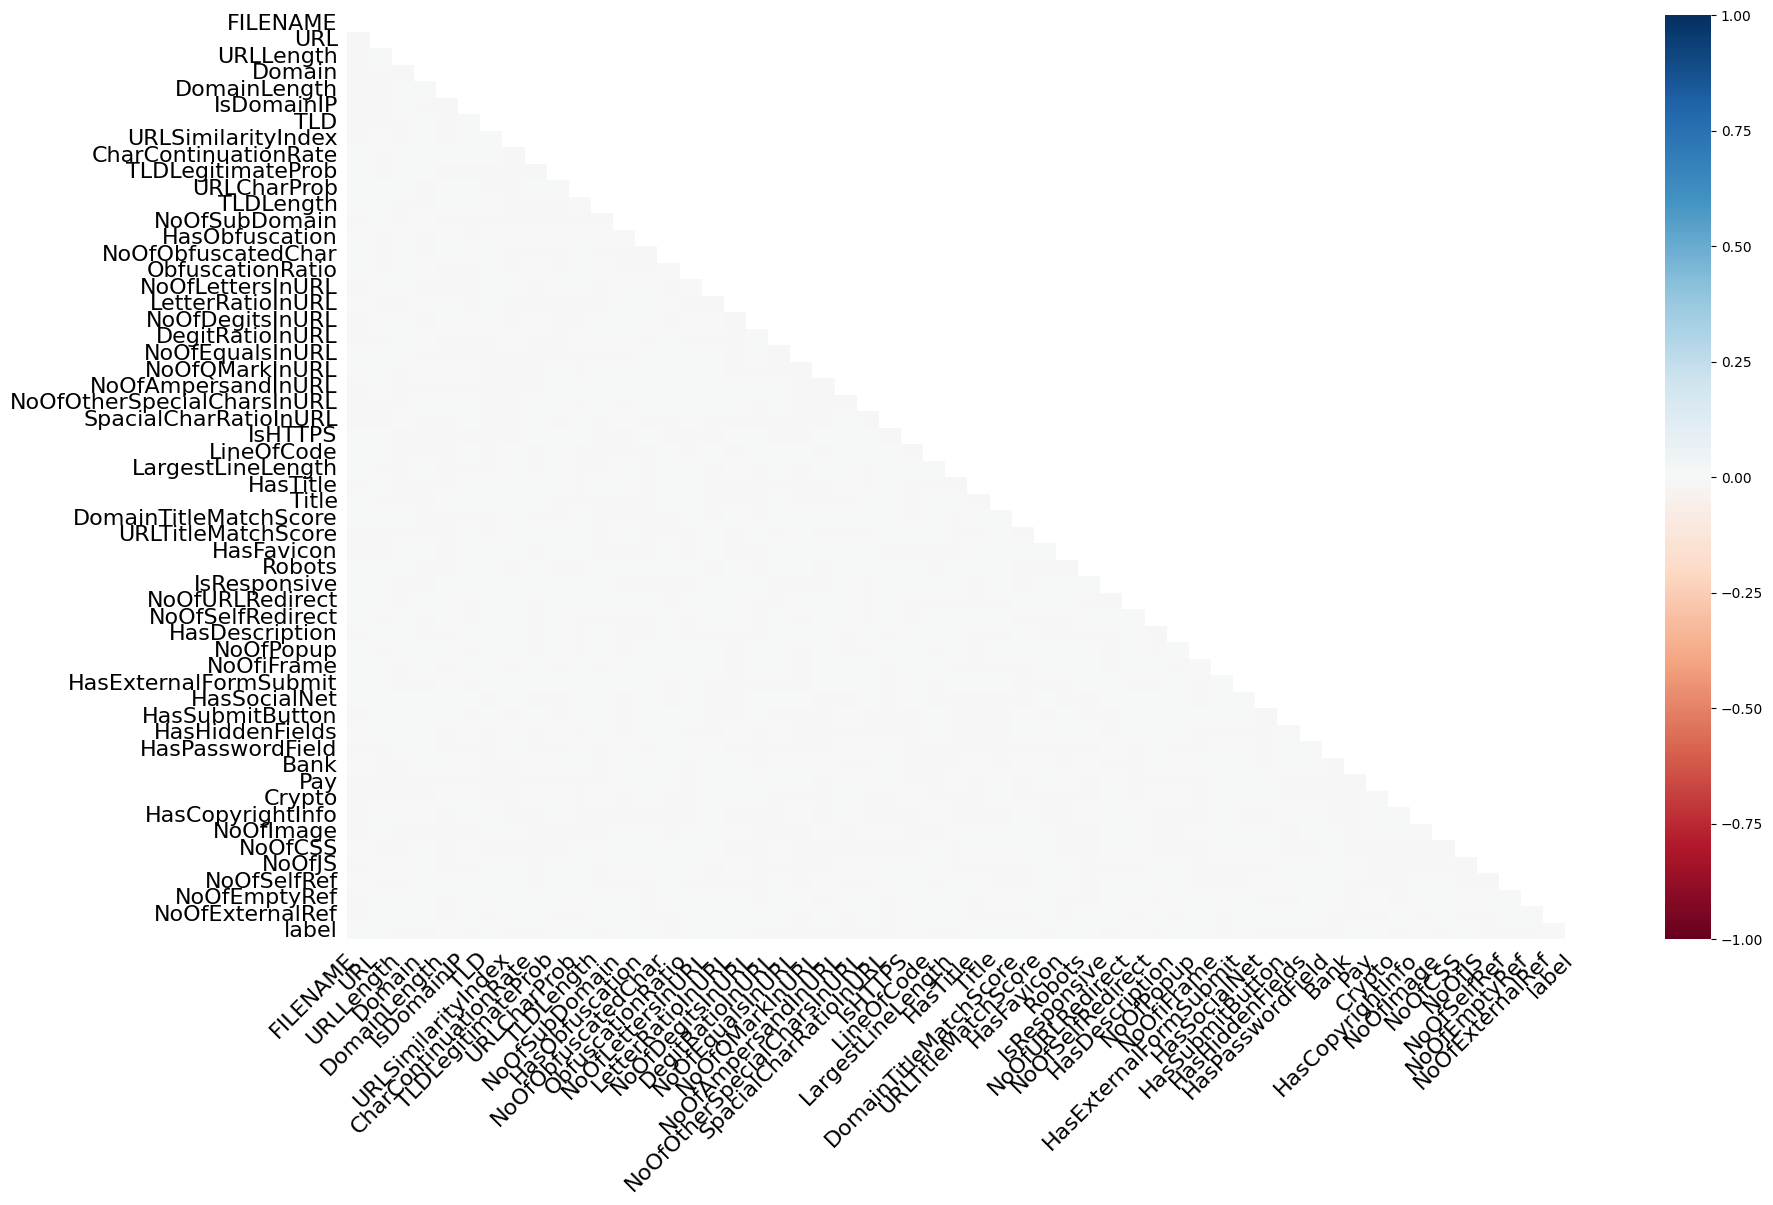

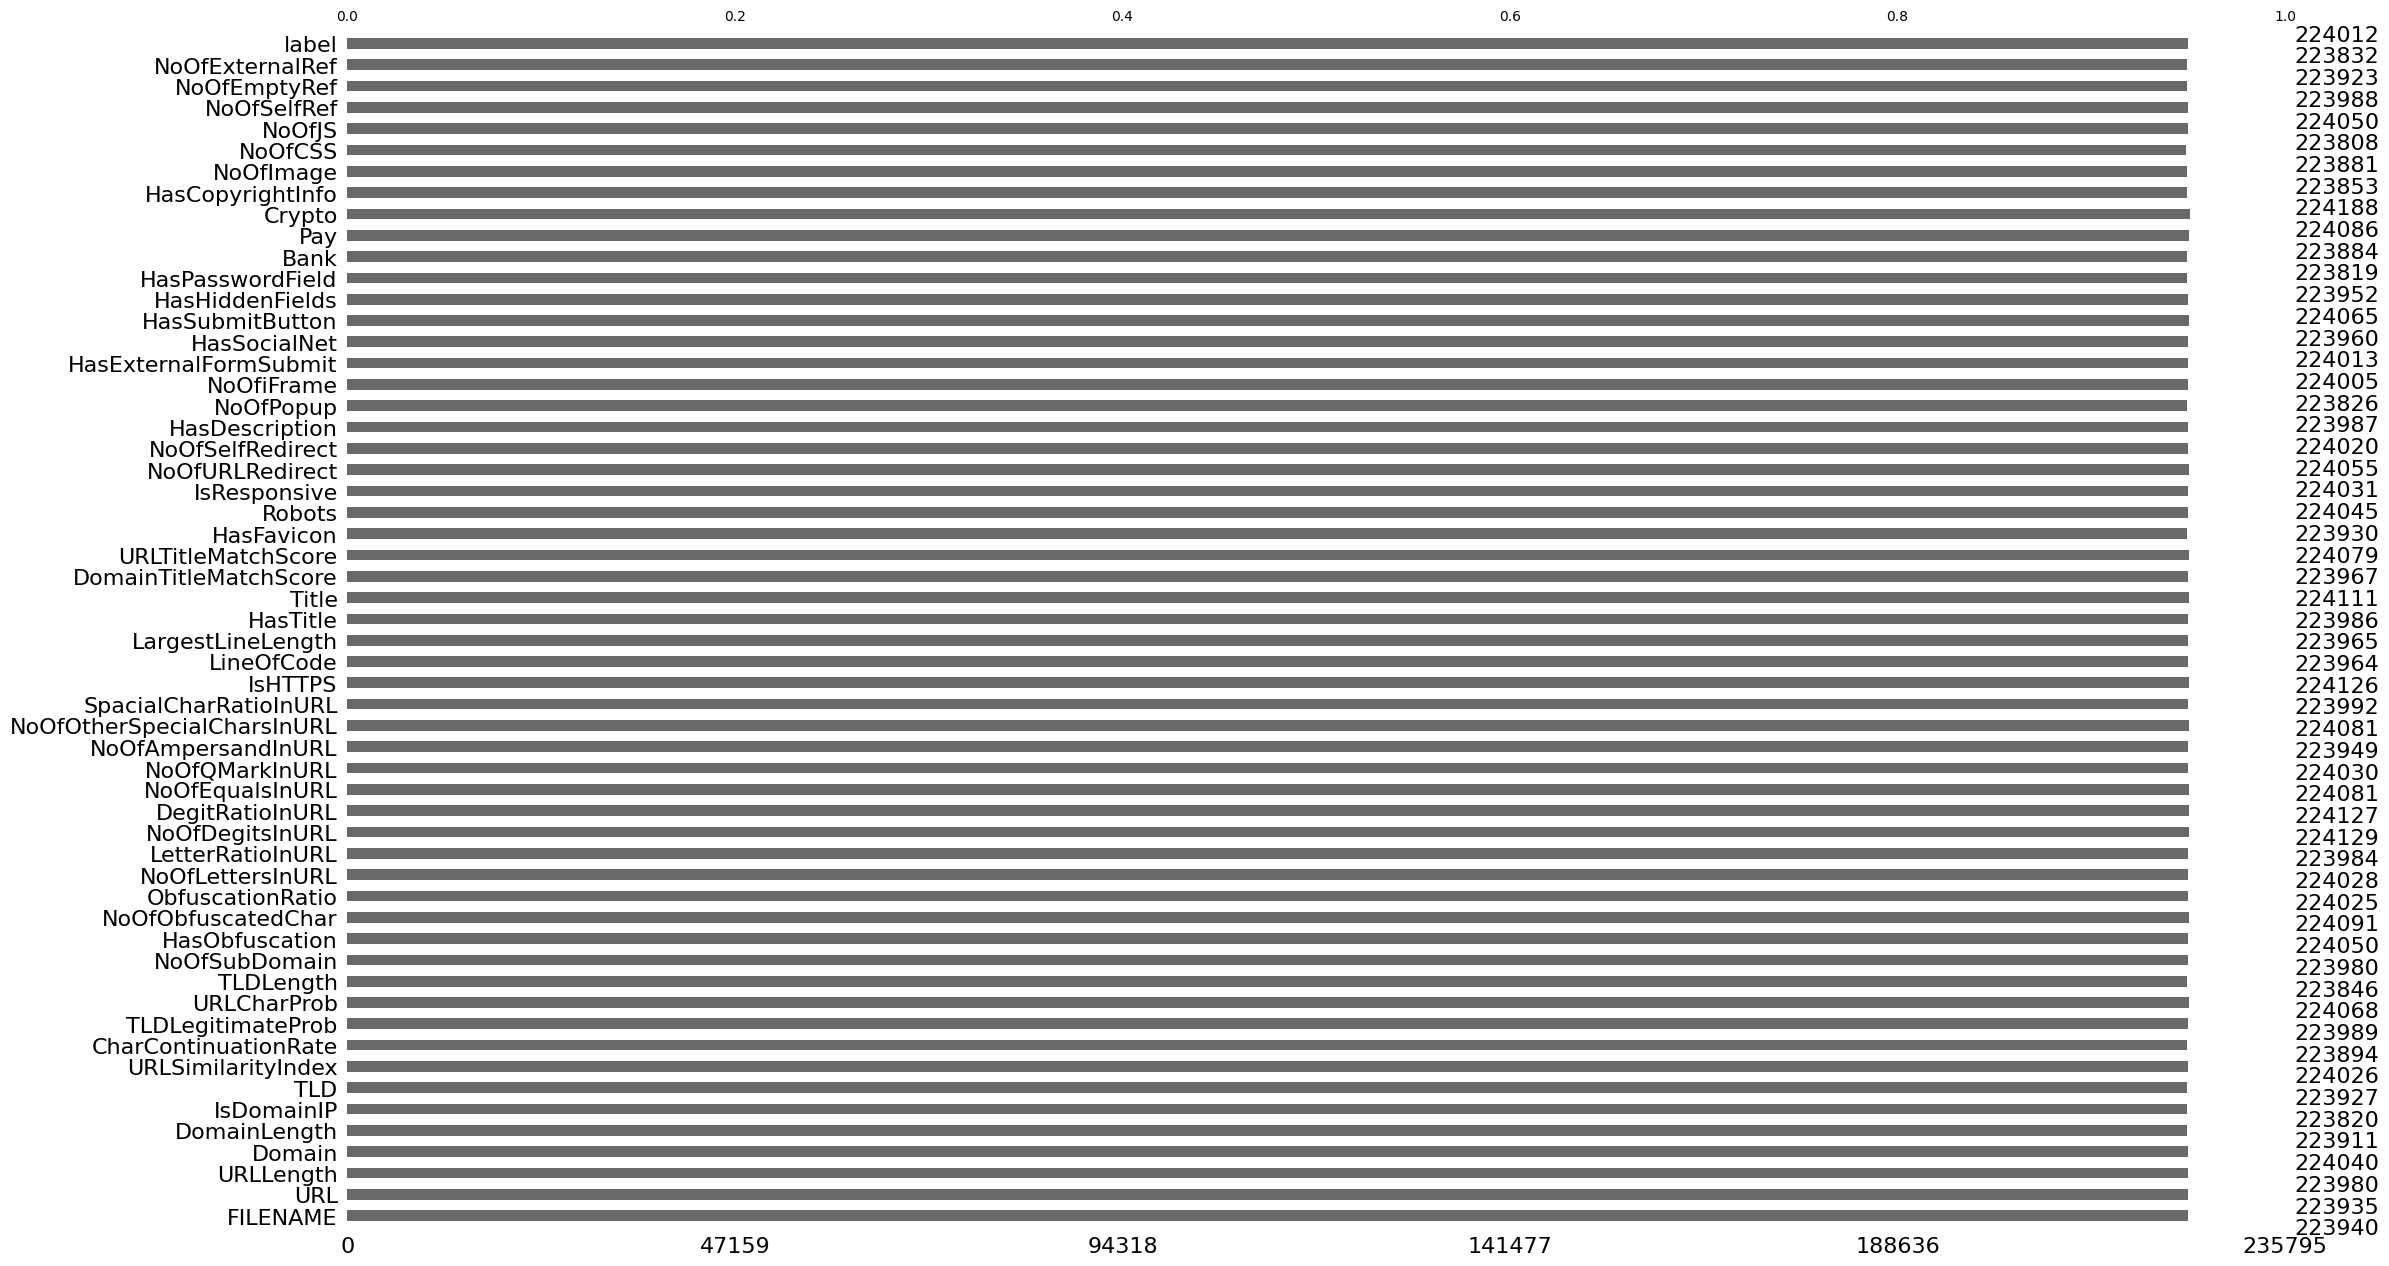

In [5]:
# I find that people use missingno library for visualizing missing data
import missingno as msno
import matplotlib.pyplot as plt
msno.matrix(df_raw)
plt.show()
msno.heatmap(df_raw)
plt.show()
msno.bar(df_raw)
plt.show()
# conclusion: The Missing Value Analysis confirms that the data are MCAR.

In [20]:
# I want to use MICE for imputing missing values
#so before that let's separate features and target to avoid data leakage
# Also, I need to check categorical column for encoding methods
# label column is the target column 0 for legitimate and 1 for phishing
X = df_raw.drop('label', axis=1)
y = df_raw['label']
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")
df_summary = df_raw[categorical_cols].nunique().reset_index()
print(df_summary)
print(f"Total Missing Values: {df_raw.isnull().sum().sum()}")

Categorical columns: ['FILENAME', 'URL', 'Domain', 'TLD', 'Title']
      index       0
0  FILENAME  223940
1       URL  223548
2    Domain  209373
3       TLD     688
4     Title  188246
Total Missing Values: 661186


In [7]:
#there are categorical columns with high cardinality, so I will drop them bc they may not contribute much to the model performance
#before that I want to see TLD column 
tld_counts = X['TLD'].value_counts()
print(tld_counts)
# even TLD column has high cardinality, it looks like it may contribute to the model performance, so I will keep it BUT I will drop other high cardinality columns
# I need to organize TLD for encoding so it looks like there are lots of unique TLDs with low frequencies, I will group them into 'other' category
tld_threshold = 100  # Define a threshold for minimum frequency
tld_frequent = tld_counts[tld_counts >= tld_threshold].index
X['TLD'] = X['TLD'].apply(lambda x: x if x in tld_frequent else 'other')
#see how much we reduced unique TLDs
print(f"Unique TLDs after grouping: {X['TLD'].nunique()}")

TLD
com       106857
org        17848
net         6739
app         6185
uk          6088
           ...  
expert         1
citic          1
koeln          1
47             1
ne             1
Name: count, Length: 688, dtype: int64
Unique TLDs after grouping: 99


In [8]:
#we drop to 99 it is still high cardinality but I have to keep it for model performance
# we can't use target or counting encoding methods for imputation because they may cause data leakage and we can't use one-hot encoding because of high cardinality
# so I will try one-hot encoding Which is a problem bc 99 columns creates about 23 million cells but I will try it anyway. I believe my computer can handle it
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OneHotEncoder
X_ohe = X.copy()
X_ohe['TLD'] = X_ohe['TLD'].astype(str) # Ensure TLD is of type string
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
tld_encoded_array = ohe.fit_transform(X_ohe[['TLD']])
tld_column_names = ohe.get_feature_names_out(['TLD'])
tld_df = pd.DataFrame(tld_encoded_array, columns=tld_column_names, index=X_ohe.index)

In [9]:
#check the shape of new tld_df
print(f"Shape of one-hot encoded TLD DataFrame: {tld_df.shape}")
print(tld_df.head())

Shape of one-hot encoded TLD DataFrame: (235795, 99)
   TLD_ae  TLD_app  TLD_ar  TLD_at  TLD_au  TLD_be  TLD_bg  TLD_biz  TLD_br  \
0     0.0      0.0     0.0     0.0     0.0     0.0     0.0      0.0     0.0   
1     0.0      0.0     0.0     0.0     0.0     0.0     0.0      0.0     0.0   
2     0.0      0.0     0.0     0.0     0.0     0.0     0.0      0.0     0.0   
3     0.0      0.0     0.0     0.0     0.0     0.0     0.0      0.0     0.0   
4     0.0      0.0     0.0     0.0     0.0     0.0     0.0      0.0     0.0   

   TLD_ca  ...  TLD_tv  TLD_tw  TLD_ua  TLD_uk  TLD_us  TLD_vn  TLD_work  \
0     0.0  ...     0.0     0.0     0.0     0.0     0.0     0.0       0.0   
1     0.0  ...     0.0     0.0     0.0     0.0     0.0     0.0       0.0   
2     0.0  ...     0.0     0.0     0.0     1.0     0.0     0.0       0.0   
3     0.0  ...     0.0     0.0     0.0     0.0     0.0     0.0       0.0   
4     0.0  ...     0.0     0.0     0.0     0.0     0.0     0.0       0.0   

   TLD_ws  TLD_

In [10]:
# OneHotEncoder might turn a missing value into all zeros (0,0,0...).
# MICE needs to see 'NaN' to know it should fill that spot.
# We find rows where TLD was originally null and force the new columns to be NaN.
missing_mask = X['TLD'].isnull() | (X['TLD'] == 'nan') # Check for both Null and string 'nan'
tld_df.loc[missing_mask, :] = np.nan

In [12]:
# Drop the original text 'TLD' with other categorical column and attach the 99 new binary columns
X_numeric = X_ohe.drop(columns=['FILENAME', 'URL', 'Domain', 'TLD', 'Title'])
X_final_input = pd.concat([X_numeric, tld_df], axis=1)

In [13]:
# Run MICE
# random_state ensures reproducibility for your teacher
mice_imputer = IterativeImputer(max_iter=10, random_state=16) #I am from Bursa Turkey so I set random_state to 16 codex of Bursa
X_imputed_array = mice_imputer.fit_transform(X_final_input)

In [14]:
X_imputed_df = pd.DataFrame(X_imputed_array, columns=X_final_input.columns)

In [15]:
imputed_tld_part = X_imputed_df[tld_column_names]

In [16]:
predicted_tld_cols = imputed_tld_part.idxmax(axis=1)

In [17]:
X_imputed_df['TLD_Final'] = predicted_tld_cols.str.replace('TLD_', '')

In [18]:
final_cols_to_drop = list(tld_column_names)
df_clean = X_imputed_df.drop(columns=final_cols_to_drop)

In [19]:
print("\nImputation Complete!")
print(df_clean[['TLD_Final']].head())
print(f"Remaining Missing Values: {df_clean.isnull().sum().sum()}")


Imputation Complete!
  TLD_Final
0       com
1     other
2        uk
3       com
4       org
Remaining Missing Values: 0


In [23]:
#look into TLD
tld_final_counts = df_clean['TLD_Final'].value_counts()
print(tld_final_counts)

TLD_Final
com      106857
other     19105
org       17848
net        6739
app        6185
          ...  
th          111
pe          108
pro         106
sh          105
cfd         100
Name: count, Length: 99, dtype: int64


In [24]:
#export our cleaned dataframe
df_clean.to_csv('Phishing_URL_ds_cleaned.csv', index=False)